# Variant A — differentiable finite-volume (method-of-lines) DWO solver

Standalone from the PINN line. **Why this oscillates and the PINN did not:** the density-wave
oscillation (DWO) is a self-excited *dynamical* instability. Marching a spatially-coupled discrete
system forward in time is **causal** — the unstable eigenmode grows on its own and saturates into a
limit cycle; upwind advection of the enthalpy (density) wave supplies the physical downstream
time-lag that closes the flow<->pressure-drop feedback loop. The all-at-once PINN optimization
instead relaxes onto the stable quasi-steady manifold, so it never sees the oscillation.

**Model** (single-pressure: density depends on enthalpy at the reference pressure, `rho=rho(h)`):
state = cell enthalpies `h_j`, plus the inlet flux `G_in`.
- energy   : `dh/dt = (NQ'(t) - G h_z)/rho`  (upwind, flow>0) — the density wave
- mass     : `G_z = -rho_t = -chi h_t`  -> `G(z)` by integrating continuity from the inlet
- momentum : channel-integrated, **exact inertia** `d/dt \int_0^1 G dz = dpi_imposed - dp_consumed`;
  `\int G dz = G_in - I_S` from continuity, so the distributed-storage ('channel breathing') term
  is included and there is NO free inertia knob. `dp_consumed` = flux + gravity + distributed
  friction + inlet/outlet local losses. (Legacy lumped `Lambda dG_in/dt` kept via `inertia=<float>`.)

All closures (EOS `rho/chi`, `distributed_friction`, heating `NQ'`, `kin/kout`, `Fr`, `dpi*`) are
**reused verbatim** from `Physics` — no new physics, **no data, no network**. The PINN is not needed
to produce the oscillation; this is the honest 'variant A' demonstrator.

**Numerics matter:** DWO is sensitive to dissipation. First-order upwind (space) + backward-Euler
(time) are both dissipative; too coarse a grid **damps the oscillation** and you see only the smooth
envelope. `N>=600`, `dt<=0.05` recovers the DWO here. Treat `N`, `dt`, `inertia` as the knobs and
do a grid-convergence check before trusting amplitude/period quantitatively.

In [27]:
import sys
import math
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from iapws import IAPWS97
import torch
import torch.nn as nn

sys.path.append("/mnt/data")
from eos_iapws_spline import EOSGridSpec, IAPWSDensitySpline

In [28]:
@dataclass(frozen=True)
class Forcing:
    time: np.ndarray
    tau: np.ndarray
    power: np.ndarray
    flow_in: np.ndarray
    flow_out: np.ndarray
    ntpc: np.ndarray
    mdot0: float

    @classmethod
    def from_excel(cls, path, t0_ramp=2.0):
        df = pd.read_excel(path)

        cols = ["Time [s]", "Flow-in [kg/s]", "Flow-out [kg/s]", "Power [W]", "NTPC"]
        df = df[cols].apply(pd.to_numeric, errors="coerce").dropna()
        df = df.sort_values("Time [s]")

        pre = df[
            (df["Time [s]"] >= 1.0)
            & (df["Time [s]"] <= 1.8)
            & (df["Power [W]"].abs() < 1e-12)
        ]

        mdot0 = float(pre["Flow-in [kg/s]"].mean())

        df = df[df["Time [s]"] >= t0_ramp].copy()
        time = df["Time [s]"].to_numpy()
        tau = time - t0_ramp

        return cls(
            time=time,
            tau=tau,
            power=df["Power [W]"].to_numpy(),
            flow_in=df["Flow-in [kg/s]"].to_numpy(),
            flow_out=df["Flow-out [kg/s]"].to_numpy(),
            ntpc=df["NTPC"].to_numpy(),
            mdot0=mdot0,
        )

    def power_torch(self, tau):
        x = tau.detach().cpu().numpy().reshape(-1)
        y = np.interp(x, self.tau, self.power)

        return torch.as_tensor(
            y,
            dtype=tau.dtype,
            device=tau.device,
        ).reshape_as(tau)

In [29]:
eos_path = Path("iapws_density_spline_25mpa.npz")

if eos_path.exists():
    eos = IAPWSDensitySpline.load(eos_path)
else:
    spec = EOSGridSpec(
        p_min=24.5e6,
        p_max=25.5e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_p=64,
        n_h=256,
        kx=3,
        ky=3,
        smoothing=0.0,
    )

    eos = IAPWSDensitySpline.build(spec)
    eos.save(eos_path)

In [30]:
@dataclass(frozen=True)
class MuGridSpec:
    p_ref: float = 25.0e6
    h_min: float = 0.75e6
    h_max: float = 4.20e6
    n_h: int = 512


class IAPWSViscositySpline:
    def __init__(self, spec, h_grid, mu_grid):
        self.spec = spec
        self.h_grid = np.asarray(h_grid, dtype=np.float64)
        self.mu_grid = np.asarray(mu_grid, dtype=np.float64)
        self.spline = CubicSpline(self.h_grid, self.mu_grid, bc_type="natural")

    @classmethod
    def build(cls, spec=MuGridSpec()):
        h_grid = np.linspace(spec.h_min, spec.h_max, spec.n_h)
        mu_grid = np.empty_like(h_grid)

        for i, h in enumerate(h_grid):
            mu_grid[i] = IAPWS97(P=spec.p_ref / 1e6, h=h / 1e3).mu

        return cls(spec, h_grid, mu_grid)

    def eval(self, h_abs, clip=True):
        h = np.asarray(h_abs, dtype=np.float64)

        if clip:
            h = np.clip(h, self.h_grid[0], self.h_grid[-1])

        return {
            "mu": self.spline(h),
            "mu_h": self.spline(h, 1),
        }

    def eval_torch(self, h_abs, clip=True):
        out = self.eval(
            h_abs.detach().cpu().numpy(),
            clip=clip,
        )

        mu_value = torch.as_tensor(
            out["mu"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu_h = torch.as_tensor(
            out["mu_h"],
            device=h_abs.device,
            dtype=h_abs.dtype,
        )

        mu = mu_value + mu_h * (h_abs - h_abs.detach())

        return {
            "mu": mu,
            "mu_h": mu_h,
        }


def smooth_abs(x, eps=1e-6):
    return torch.sqrt(x * x + eps * eps)


def darcy_lambda_torch(
    Re,
    roughness,
    Dh,
    model="swamee",
    Re_transition=2300.0,
    blend_width=200.0,
):
    Re = torch.clamp(Re, min=1.0)

    lam_laminar = 64.0 / Re

    if model == "blasius":
        lam_turb = 0.3164 / Re.pow(0.25)

    elif model == "swamee":
        rel = roughness / Dh
        arg = rel / 3.7 + 5.74 / Re.pow(0.9)
        lam_turb = 0.25 / torch.log10(arg).pow(2.0)

    else:
        raise ValueError("model must be 'blasius' or 'swamee'")

    s = torch.sigmoid((Re - Re_transition) / blend_width)

    return (1.0 - s) * lam_laminar + s * lam_turb

In [31]:
mu_spline = IAPWSViscositySpline.build(
    MuGridSpec(
        p_ref=25.0e6,
        h_min=0.75e6,
        h_max=4.20e6,
        n_h=512,
    )
)

In [32]:
@dataclass(frozen=True)
class Case:
    L: float
    Dh: float
    A: float

    p_ref: float
    p_out: float
    dp_ch: float
    p_in: float

    rho_pc: float
    h_pc: float
    Cp_pc: float
    beta_pc: float

    nspc: float
    h0_star: float

    kin: float
    kout: float
    Lambda: float
    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float
    g: float

    mdot0: float
    G0: float
    rho0: float
    rho0_star: float
    w0: float

    G0_star: float
    dpi_star: float
    Fr: float

    roughness: float
    friction_model: str
    Re0: float
    lambda0: float
    Lambda_ref: float

    NQ_scale: float
    mass_scale: float
    mom_mid_scale: float
    mom_delta_scale: float
    energy_scale: float

    t_end_star: float
    t_kink_star: float

    @classmethod
    def build(cls, forcing, eos, nspc=2.0, alpha=0.02):
        L = 4.2672
        Dh = 8.36e-3
        A = math.pi * Dh**2 / 4

        p_ref = 25.0e6
        p_out = 25.0e6
        dp_ch = 0.12e6
        p_in = p_out + dp_ch

        rho_pc = 317.0348
        h_pc = 2152539.0
        Cp_pc = 76444.66
        beta_pc = 0.1285075

        h0_star = -nspc
        h0_abs = h_pc + (Cp_pc / beta_pc) * h0_star

        rho0 = float(np.asarray(eos.eval(p_ref, h0_abs)["rho"]))
        rho0_star = rho0 / rho_pc

        G0 = forcing.mdot0 / A
        w0 = G0 / rho0

        kin = 20.0
        kout = 20.0
        roughness = 2.5e-5
        friction_model = "swamee"   # можно заменить на "blasius"
        g = 9.81

        mu0 = IAPWS97(P=p_ref / 1e6, h=h0_abs / 1e3).mu
        Re0 = G0 * Dh / mu0

        if Re0 < 2300.0:
            lambda0 = 64.0 / Re0
        else:
            if friction_model == "blasius":
                lambda0 = 0.3164 / Re0**0.25
            elif friction_model == "swamee":
                lambda0 = 0.25 / (
                    np.log10(roughness / (3.7 * Dh) + 5.74 / Re0**0.9) ** 2
                )
            else:
                raise ValueError("friction_model must be 'blasius' or 'swamee'")

        Lambda_ref = lambda0 * L / (2.0 * Dh)

        # оставляем поле Lambda, чтобы старый код не ломался
        Lambda = Lambda_ref

        G0_star = G0 / (rho_pc * w0)
        dpi_star = dp_ch / (rho_pc * w0**2)
        Fr = w0**2 / (g * L)

        NQ = (
            beta_pc
            / Cp_pc
            * forcing.power
            / (rho_pc * w0 * A)
        )
        NQ_scale = max(float(np.max(np.abs(NQ))), 1.0)

        mass_scale = max(abs(G0_star), 1.0)
        energy_scale = NQ_scale
        mom_mid_scale = max(abs(dpi_star), 1.0)

        delta_max = (
            1.0 / math.sqrt(2.0 * math.pi)
            / (alpha * (0.5 * (1.0 + math.erf(1.0 / (alpha * math.sqrt(2.0)))) - 0.5))
        )

        local_coeff_max = Lambda + 0.5 * max(kin, kout) * delta_max
        local_loss_scale = local_coeff_max * G0_star**2 / rho0_star

        mom_delta_scale = max(abs(dpi_star), local_loss_scale, 1.0)

        t_end_star = float(forcing.tau[-1] * w0 / L)
        t_kink_star = float(10.0 * w0 / L)

        return cls(
            L=L,
            Dh=Dh,
            A=A,
            p_ref=p_ref,
            p_out=p_out,
            dp_ch=dp_ch,
            p_in=p_in,
            rho_pc=rho_pc,
            h_pc=h_pc,
            Cp_pc=Cp_pc,
            beta_pc=beta_pc,
            nspc=nspc,
            h0_star=h0_star,
            kin=kin,
            kout=kout,
            Lambda=Lambda,
            roughness=roughness,
            friction_model=friction_model,
            Re0=Re0,
            lambda0=lambda0,
            Lambda_ref=Lambda_ref,
            g=g,
            mdot0=forcing.mdot0,
            G0=G0,
            rho0=rho0,
            rho0_star=rho0_star,
            w0=w0,
            G0_star=G0_star,
            dpi_star=dpi_star,
            Fr=Fr,
            NQ_scale=NQ_scale,
            mass_scale=mass_scale,
            mom_mid_scale=mom_mid_scale,
            mom_delta_scale=mom_delta_scale,
            energy_scale=energy_scale,
            t_end_star=t_end_star,
            t_kink_star=t_kink_star,
        )

In [33]:
path = Path("Churkin-Kout20-Nspc2.0-Transient-Water-Vertical.xlsx")

forcing = Forcing.from_excel(path)
case = Case.build(forcing, eos, nspc=2.0, alpha=0.02)

print(f"mdot0           = {case.mdot0:.8f} kg/s")
print(f"rho0            = {case.rho0:.6f} kg/m3")
print(f"rho0*           = {case.rho0_star:.6f}")
print(f"w0              = {case.w0:.6f} m/s")
print(f"G0*             = {case.G0_star:.6f}")
print(f"Delta pi*       = {case.dpi_star:.6f}")
print(f"Fr              = {case.Fr:.6e}")
print(f"NQ scale        = {case.NQ_scale:.6f}")
print(f"mass scale      = {case.mass_scale:.6f}")
print(f"mom mid scale   = {case.mom_mid_scale:.6f}")
print(f"mom delta scale = {case.mom_delta_scale:.6f}")
print(f"energy scale    = {case.energy_scale:.6f}")
print(f"T_end*          = {case.t_end_star:.3f}")
print(f"Re0             = {case.Re0:.3f}")
print(f"lambda0         = {case.lambda0:.6f}")
print(f"Lambda_ref      = {case.Lambda_ref:.6f}")
print(f"friction model  = {case.friction_model}")

mdot0           = 0.09432138 kg/s
rho0            = 855.637767 kg/m3
rho0*           = 2.698876
w0              = 2.008250 m/s
G0*             = 2.698876
Delta pi*       = 93.850980
Fr              = 9.634374e-02
NQ scale        = 4.913639
mass scale      = 2.698876
mom mid scale   = 93.850980
mom delta scale = 1095.658303
energy scale    = 4.913639
T_end*          = 846.089
Re0             = 114090.521
lambda0         = 0.027530
Lambda_ref      = 7.026021
friction model  = swamee


In [34]:
def d(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def mse(x):
    return torch.mean(x**2)


def normal_pdf(x):
    return torch.exp(-0.5 * x**2) / math.sqrt(2.0 * math.pi)


def normal_cdf(x):
    return 0.5 * (1.0 + torch.erf(x / math.sqrt(2.0)))


def delta_inlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(1.0 / a) - normal_cdf(torch.zeros_like(a)))

    return normal_pdf(z / a) / denom


def delta_outlet(z, alpha):
    a = torch.as_tensor(alpha, dtype=z.dtype, device=z.device)
    denom = a * (normal_cdf(torch.zeros_like(a)) - normal_cdf(-1.0 / a))

    return normal_pdf((z - 1.0) / a) / denom

In [35]:
@dataclass(frozen=True)
class LossWeights:
    # per-equation weights INSIDE the per-time residual L_r(t_i)
    mass: float = 1.0
    mom: float = 1.0
    energy: float = 1.0

    # causal anchors (Wang+2024): IC is the t_0 segment, BC folded per-time so it
    # is gated by the same causal front as the PDE residual.
    causal_ic: float = 1000.0  # lambda_ic, matches CausalPINNs (loss =
                               # mean(W*L_t) + lambda_ic*L_ic, IC full weight).
                               # L_ic also enters every w_i's exponent, so driving
                               # IC -> ~1e-5 is what OPENS the causal gate.
    causal_bc: float = 30.0

    # causal time / space resolution
    Nt: int = 64              # number of sorted time segments
    Nz_pde: int = 96          # spatial points per time for the PDE residual
    Nz_keeper: int = 193      # spatial points per time for the integral keepers

    # integral keepers -- now causally weighted by the SAME w_i (no tail
    # concentration). They ride on the front but do not define it.
    mom_integral: float = 20.0
    energy_integral: float = 20.0
    mass_integral: float = 20.0

    # legacy fields kept so pde_loss / the diagnostic+ablation cells still
    # construct. Not used by the causal path.
    ic: float = 20.0
    bc: float = 20.0
    mom_in: float = 1.0
    mom_mid: float = 1.0
    mom_out: float = 1.0


class Physics:
    def __init__(self, model, eos, mu_spline, case, forcing, alpha=0.02):
        self.model = model
        self.eos = eos
        self.mu_spline = mu_spline
        self.case = case
        self.forcing = forcing
        self.alpha = alpha

    def fields(self, z, t):
        G_hat, h_hat, Pi_hat = self.model(z, t)

        G = self.case.G0_star * G_hat
        h = self.case.nspc * h_hat
        pi = self.case.dpi_star * Pi_hat

        return G, h, pi, G_hat, h_hat, Pi_hat

    def eos25(self, h_star):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h_star
        p_abs = torch.full_like(h_abs, self.case.p_ref)

        raw = self.eos.eval_torch(p_abs, h_abs)

        rho_value = raw["rho"] / self.case.rho_pc

        chi_h = (
            self.case.Cp_pc
            / (self.case.beta_pc * self.case.rho_pc)
            * raw["rho_h"]
        )

        rho_star = rho_value + chi_h * (h_star - h_star.detach())

        return rho_star, chi_h

    def NQ_prime(self, t):
        tau = t * self.case.L / self.case.w0
        Q = self.forcing.power_torch(tau)

        return (
            self.case.beta_pc
            / self.case.Cp_pc
            * Q
            / (self.case.rho_pc * self.case.w0 * self.case.A)
        )
    
    def distributed_friction(self, G, h, rho):
        h_abs = self.case.h_pc + (self.case.Cp_pc / self.case.beta_pc) * h

        mu = self.mu_spline.eval_torch(h_abs)["mu"]

        G_abs_dim = self.case.rho_pc * self.case.w0 * smooth_abs(G, eps=1e-6)

        Re = G_abs_dim * self.case.Dh / mu

        lambda_darcy = darcy_lambda_torch(
            Re=Re,
            roughness=self.case.roughness,
            Dh=self.case.Dh,
            model=self.case.friction_model,
        )

        Lambda_dyn = lambda_darcy * self.case.L / (2.0 * self.case.Dh)

        signed_loss_flux = G * smooth_abs(G, eps=1e-6) / rho

        return Lambda_dyn, signed_loss_flux, Re, lambda_darcy

    def residuals_raw(self, z, t, include_local=True):
        G, h, pi, _, _, _ = self.fields(z, t)

        G_t = d(G, t)
        G_z = d(G, z)

        h_t = d(h, t)
        h_z = d(h, z)

        pi_z = d(pi, z)

        rho, chi_h = self.eos25(h)

        rho_t = chi_h * h_t
        rho_z = chi_h * h_z

        mom_flux = G**2 / rho

        mom_flux_z = (
            2.0 * G * G_z / rho
            - G**2 * rho_z / rho**2
        )

        Lambda_dyn, signed_loss_flux, Re, lambda_darcy = self.distributed_friction(
            G=G,
            h=h,
            rho=rho,
        )

        delta0 = delta_inlet(z, self.alpha)
        delta1 = delta_outlet(z, self.alpha)

        distributed_loss = Lambda_dyn * signed_loss_flux

        # Local inlet/outlet losses are physically pressure JUMPS at the faces,
        # NOT a distributed interior body force. The Gaussian-smeared delta puts
        # a near-singular spike (G|G|/rho_out blows up as rho_out -> 0.4 when hot)
        # into the POINTWISE residual that a smooth tanh net cannot resolve -> a
        # high outlet-zone residual that drives the optimizer to the cold basin.
        # We therefore EXCLUDE the local term from the pointwise R_mom and enforce
        # it ONLY in the integral momentum balance (integral_mom_loss), where the
        # delta integrates to a finite jump 1/2 k G|G|/rho (no spike). The rho is
        # still anchored at the end face. include_local defaults True so the
        # method stays general; residuals_scaled calls it with include_local=False.
        if include_local:
            z0 = torch.zeros_like(t)
            z1 = torch.ones_like(t)
            _, h_in_ep, _, _, _, _ = self.fields(z0, t)
            _, h_out_ep, _, _, _, _ = self.fields(z1, t)
            rho_in_ep, _ = self.eos25(h_in_ep)
            rho_out_ep, _ = self.eos25(h_out_ep)

            loss_flux_num = G * smooth_abs(G, eps=1e-6)  # numerator G|G|

            local_loss = (
                0.5 * self.case.kin * delta0 * (loss_flux_num / rho_in_ep)
                + 0.5 * self.case.kout * delta1 * (loss_flux_num / rho_out_ep)
            )
        else:
            local_loss = torch.zeros_like(G)

        R_mass = rho_t + G_z

        R_mom = (
            G_t
            + mom_flux_z
            + pi_z
            + rho / self.case.Fr
            + distributed_loss
            + local_loss
        )

        R_energy = rho * h_t + G * h_z - self.NQ_prime(t) + h * R_mass

        return R_mass, R_mom, R_energy

    def residuals_scaled(self, z, t, zone):
        # Pointwise momentum WITHOUT the delta-smeared local losses (those are a
        # face jump, enforced in integral_mom_loss). The interior R_mom is now
        # smooth in every zone, so all zones share the mid scale (dpi_star). The
        # old per-zone mom_delta_scale (~1096) only existed to tame the removed
        # spike; keeping it here would under-weight the in/out zones ~12x.
        R_mass, R_mom, R_energy = self.residuals_raw(z, t, include_local=False)

        R_mass = R_mass / self.case.mass_scale
        R_energy = R_energy / self.case.energy_scale
        R_mom = R_mom / self.case.mom_mid_scale  # zone kept for signature compat

        return R_mass, R_mom, R_energy

    def pde_loss(self, points, weights):
        mass_losses: dict = {}
        energy_losses: dict = {}
        mom_losses: dict = {}

        for zone in ["in", "mid", "out"]:
            z, t = points[zone]
            R_mass, R_mom, R_energy = self.residuals_scaled(z, t, zone)

            mass_losses[zone] = mse(R_mass)
            energy_losses[zone] = mse(R_energy)
            mom_losses[zone] = mse(R_mom)

        L_mass = (
            mass_losses["in"]
            + mass_losses["mid"]
            + mass_losses["out"]
        ) / 3.0

        L_energy = (
            energy_losses["in"]
            + energy_losses["mid"]
            + energy_losses["out"]
        ) / 3.0

        L_mom = (
            weights.mom_in * mom_losses["in"]
            + weights.mom_mid * mom_losses["mid"]
            + weights.mom_out * mom_losses["out"]
        )

        return {
            "mass": L_mass,
            "mass_in": mass_losses["in"],
            "mass_mid": mass_losses["mid"],
            "mass_out": mass_losses["out"],
            "mom": L_mom,
            "mom_in": mom_losses["in"],
            "mom_mid": mom_losses["mid"],
            "mom_out": mom_losses["out"],
            "energy": L_energy,
            "energy_in": energy_losses["in"],
            "energy_mid": energy_losses["mid"],
            "energy_out": energy_losses["out"],
        }

    def ic_loss(self, points):
        z, t = points
        G, h, _, _, _, _ = self.fields(z, t)

        R_G = G / self.case.G0_star - 1.0
        R_h = h / self.case.nspc + 1.0

        return {
            "ic_G": mse(R_G),
            "ic_h": mse(R_h),
        }

    def bc_loss(self, points):
        z_in, t_in = points["in"]
        z_out, t_out = points["out"]

        _, h_in, pi_in, _, _, _ = self.fields(z_in, t_in)
        _, _, pi_out, _, _, _ = self.fields(z_out, t_out)

        R_h_in = h_in / self.case.nspc + 1.0

        # Imposed pressure drop (Ambrosini 2010; Churkin TEMPA-SC):
        # Delta p across the channel is fixed, the flow rate is free to oscillate.
        # One constraint on the DIFFERENCE pi*(0,t) - pi*(1,t) = Delta pi*,
        # plus a gauge anchor pi*(1,t) = 0 (p_out = 25 MPa reference).
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star

        return {
            "bc_h_in": mse(R_h_in),
            "bc_dp": mse(R_dp),
            "bc_pi_out": mse(R_pi_out),
        }

    # =====================================================================
    # Causal training (Wang, Sankaran, Perdikaris, CMAME 2024; arXiv:2203.07404)
    # =====================================================================
    def ic_loss_target(self, z, t_at, G_target, h_target):
        # IC anchor against a frozen target state (G_target, h_target)(z) at time
        # t_at -- time-marching: window k>=1 pins its left edge to the previous
        # window's end-state. Same normalization as the physical ic_loss.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        R_G = (G - G_target) / self.case.G0_star
        R_h = (h - h_target) / self.case.nspc
        return {"ic_G": mse(R_G), "ic_h": mse(R_h)}

    @torch.no_grad()
    def snapshot_state(self, z, t_at):
        # Detached (G, h) profiles at time t_at from THIS model -- becomes the IC
        # target for the next marching window.
        t = torch.full_like(z, float(t_at))
        G, h, _, _, _, _ = self.fields(z, t)
        return G.detach(), h.detach()

    def _per_time_residual(self, sampler, weights, t_grid, ic_spec=None):
        # Per-time residual L_r(t_i) = PDE (mass/mom/energy) + folded BC, computed
        # in ONE vectorized autograd pass over a (Nt, Nz) collocation grid, plus
        # the IC anchor L_0 = lambda_ic * L_ic (the t_0 segment, Eq. 3.4).
        # Returns (Lr, L0, parts): Lr is (Nt,), L0 scalar, parts for logging.
        Nt = t_grid.shape[0]

        # --- PDE residual on (Nt, Nz) points (random z per time) -------------
        z_mat = sampler.causal_space(Nt, weights.Nz_pde)     # (Nt, Nz_a)
        Nz = z_mat.shape[1]
        Z = z_mat.reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(Nz, dim=0).clone().requires_grad_(True)

        R_mass, R_mom, R_energy = self.residuals_scaled(Z, T, "mid")
        R_mass = R_mass.reshape(Nt, Nz)
        R_mom = R_mom.reshape(Nt, Nz)
        R_energy = R_energy.reshape(Nt, Nz)

        Lr_mass = (R_mass ** 2).mean(dim=1)                  # (Nt,)
        Lr_mom = (R_mom ** 2).mean(dim=1)
        Lr_energy = (R_energy ** 2).mean(dim=1)
        Lr_pde = (
            weights.mass * Lr_mass
            + weights.mom * Lr_mom
            + weights.energy * Lr_energy
        )

        # --- BC per-time (imposed Delta-p), one point per face per time ------
        z0 = torch.zeros_like(t_grid)
        z1 = torch.ones_like(t_grid)
        _, h_in, pi_in, _, _, _ = self.fields(z0, t_grid)
        _, _, pi_out, _, _, _ = self.fields(z1, t_grid)
        R_h_in = h_in / self.case.nspc + 1.0
        R_dp = (pi_in - pi_out) / self.case.dpi_star - 1.0
        R_pi_out = pi_out / self.case.dpi_star
        Lr_bc = (R_h_in ** 2 + R_dp ** 2 + R_pi_out ** 2).reshape(-1)   # (Nt,)

        # BC is NOT folded into the causal residual: imposed-Delta-p is a
        # STANDING constraint (must hold at every t). Causally gating it lets the
        # high-eps weights switch off the tail BC (w_i -> 0) -> pi_out drifts and
        # Delta-p overshoots. Returned separately, enforced uniformly below.

        # --- IC anchor (left edge of the window) -----------------------------
        # window 0: physical IC at t=0; window k>=1: seam snapshot at t_lo.
        if ic_spec is None:
            ic = self.ic_loss(sampler.ic())
        else:
            ic = self.ic_loss_target(
                ic_spec["z"], ic_spec["t_at"], ic_spec["G"], ic_spec["h"],
            )
        L_ic = ic["ic_G"] + ic["ic_h"]
        L0 = weights.causal_ic * L_ic

        parts = {
            "pde": Lr_pde.mean().detach(),
            "bc": Lr_bc.mean().detach(),
            "ic": L_ic.detach(),
        }
        return Lr_pde, L0, Lr_bc, parts

    def _keeper_vectors(self, t_grid, n_z=193):
        # SIGNED per-time integral residuals of the three keeper identities on a
        # uniform z-grid -- returns (mom_vec, energy_vec, mass_vec), each (Nt,),
        # with the autograd graph intact. Vectorized: one forward+autograd pass
        # over (Nt, Nz). Single source of truth for both the causal keeper loss
        # and keeper_time_profiles. Mirrors the old integral_*_loss term by term.
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        Nt = t_grid.shape[0]
        z_lin = torch.linspace(0.0, 1.0, n_z, device=device, dtype=dtype)
        dz = float(z_lin[1] - z_lin[0])

        Z = z_lin.reshape(1, n_z).expand(Nt, n_z).reshape(-1, 1).clone().requires_grad_(True)
        T = t_grid.reshape(-1, 1).repeat_interleave(n_z, dim=0).clone().requires_grad_(True)

        G, h, pi, _, _, _ = self.fields(Z, T)
        rho, chi_h = self.eos25(h)

        G_t = d(G, T)
        h_t = d(h, T)
        h_z = d(h, Z)
        G_z = d(G, Z)
        rho_t = chi_h * h_t

        Lambda_dyn, signed_loss_flux, _, _ = self.distributed_friction(
            G=G, h=h, rho=rho,
        )
        loss_flux_num = G * smooth_abs(G, eps=1e-6)
        di = delta_inlet(Z, self.alpha)
        do = delta_outlet(Z, self.alpha)

        def M(x):
            return x.reshape(Nt, n_z)

        flux = M(G ** 2 / rho)
        rho_m = M(rho)
        lfn_m = M(loss_flux_num)
        di_m = M(di)
        do_m = M(do)

        accel = torch.trapezoid(M(G_t), dx=dz, dim=1)            # (Nt,)
        gravity = torch.trapezoid(M(rho / self.case.Fr), dx=dz, dim=1)
        friction = torch.trapezoid(M(Lambda_dyn * signed_loss_flux), dx=dz, dim=1)
        flux_jump = flux[:, -1] - flux[:, 0]
        local_in = torch.trapezoid(
            0.5 * self.case.kin * di_m * lfn_m / rho_m[:, 0:1], dx=dz, dim=1,
        )
        local_out = torch.trapezoid(
            0.5 * self.case.kout * do_m * lfn_m / rho_m[:, -1:], dx=dz, dim=1,
        )
        rhs = accel + flux_jump + gravity + friction + local_in + local_out
        mom_vec = (rhs - self.case.dpi_star) / self.case.dpi_star   # (Nt,)

        R_mass_m = M(rho_t + G_z)
        R_energy_m = M(rho * h_t + G * h_z - self.NQ_prime(T)) + M(h) * R_mass_m
        energy_vec = torch.trapezoid(R_energy_m / self.case.energy_scale, dx=dz, dim=1)
        mass_vec = torch.trapezoid(R_mass_m / self.case.mass_scale, dx=dz, dim=1)

        return mom_vec, energy_vec, mass_vec

    def causal_pde_loss(self, sampler, weights, eps, t_lo=0.0, t_hi=None, ic_spec=None):
        # Total causal loss (Eq. 3.2-3.4) over the window (t_lo, t_hi]. Builds the
        # sorted time grid, per-time residual L_r(t_i), causal weights w_i
        # (stop-gradient), the weighted sum, and the causally weighted keepers.
        t_grid = sampler.causal_time_grid(weights.Nt, t_lo, t_hi)
        Lr, L0, Lr_bc, parts = self._per_time_residual(sampler, weights, t_grid, ic_spec)

        # causal weights from PDE residual + IC anchor ONLY (BC is enforced
        # uniformly below; it must not be gated). seg[0]=IC, seg[1:]=L_r(t_i).
        seg = torch.cat([L0.reshape(1), Lr])                 # (Nt+1,)
        S = torch.cumsum(seg, dim=0) - seg                   # exclusive prefix sum
        w = torch.exp(-eps * S.detach())                     # stop-gradient on w_i
        W = w[1:]                                            # temporal weights (== CausalPINNs W)
        w_min = W.min()
        # CausalPINNs total (KS/regular_KS.py): loss = mean(W*L_t) + L_0.
        # IC anchor at FULL weight (not averaged); residual = mean of weighted chunks.
        L_weighted = L0 + (W * Lr).mean()

        # BC: uniform FULL weight at all times (NOT causally gated)
        L_bc = weights.causal_bc * Lr_bc.mean()

        # causalized keepers: same w_i, same t_grid, no tail concentration
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, weights.Nz_keeper)
        w_k = W                                              # same temporal weights as the residual
        L_mom_int = (w_k * mom_vec ** 2).mean()
        L_energy_int = (w_k * energy_vec ** 2).mean()
        L_mass_int = (w_k * mass_vec ** 2).mean()

        total = (
            L_weighted
            + L_bc
            + weights.mom_integral * L_mom_int
            + weights.energy_integral * L_energy_int
            + weights.mass_integral * L_mass_int
        )

        logs = {
            "loss": total,
            "pde": parts["pde"],
            "bc": parts["bc"],
            "ic": parts["ic"],
            "w_min": w_min.detach(),
            "eps": float(eps),
            # raw (unweighted) mean-square keeper drift -- comparable to old logs
            "mom_int": (mom_vec ** 2).mean().detach(),
            "energy_int": (energy_vec ** 2).mean().detach(),
            "mass_int": (mass_vec ** 2).mean().detach(),
        }
        return total, logs

    def keeper_time_profiles(self, n_t=80, n_z=193):
        # SIGNED per-time keeper integrals on a uniform time grid -- for the
        # per-keeper diagnostic and ablation. Thin detached wrapper over
        # _keeper_vectors (single source of truth with the causal loss).
        p = next(self.model.parameters())
        device, dtype = p.device, p.dtype
        te = self.case.t_end_star
        t_grid = torch.linspace(0.0, te, n_t, device=device, dtype=dtype).reshape(-1, 1)
        mom_vec, energy_vec, mass_vec = self._keeper_vectors(t_grid, n_z)
        t_star = [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        t_sec = [x * self.case.L / self.case.w0 for x in t_star]
        return {
            "t_star": t_star,
            "t_sec": t_sec,
            "mom": [float(x) for x in mom_vec.detach().cpu()],
            "energy": [float(x) for x in energy_vec.detach().cpu()],
            "mass": [float(x) for x in mass_vec.detach().cpu()],
        }

    def causal_weight_profile(self, sampler, weights, eps, n_t=None):
        # Diagnostic: per-segment causal weight w_i and residual L_r(t_i) on a
        # no-jitter grid, for plotting the causal front. Read-only (detached).
        Nt = int(n_t or weights.Nt)
        t_grid = sampler.causal_time_grid(Nt, jitter=False)
        Lr, L0, _, _ = self._per_time_residual(sampler, weights, t_grid)
        seg = torch.cat([L0.reshape(1), Lr])
        S = torch.cumsum(seg, dim=0) - seg
        w = torch.exp(-eps * S)
        t_star = [0.0] + [float(x) for x in t_grid.reshape(-1).detach().cpu()]
        return {
            "t_star": t_star,
            "t_sec": [x * self.case.L / self.case.w0 for x in t_star],
            "Lr": [float(L0.detach())] + [float(x) for x in Lr.detach().cpu()],
            "w": [float(x) for x in w.detach().cpu()],
        }


## Build the physics object (no model needed — FV reuses eos25 / distributed_friction / NQ_prime)

In [36]:
physics = Physics(
    model=None,            # FV solver uses no network
    eos=eos,
    mu_spline=mu_spline,
    case=case,
    forcing=forcing,
    alpha=0.02,
)
print('physics ready. G0*=%.4f  dpi*=%.3f  Fr=%.4f  kin=%.3g  kout=%.3g  t_end*=%.1f'
      % (case.G0_star, case.dpi_star, case.Fr, case.kin, case.kout, case.t_end_star))

physics ready. G0*=2.6989  dpi*=93.851  Fr=0.0963  kin=20  kout=20  t_end*=846.1


## Smooth EOS tail extension

The IAPWS density spline is calibrated for `h_abs ∈ [0.75, 4.2] MJ/kg`. When the flow nearly
stagnates, the outlet enthalpy leaves that range and the raw spline **extrapolates polynomial
garbage** (wild `rho/chi`) — that is what blew the tail up into the unphysical saw-tooth.

Fix (no recalibration, closures untouched inside the validity range): replace `eos25` with a
version that transitions **C¹-continuously** at the range edges to a hyperbolic tail
`rho(h) = rho_e / (1 + a·(h − h_e))`, `a = −chi_e/rho_e`, which matches both `rho` and `drho/dh`
at the edge and decays like `1/h` — the ideal-gas asymptote at fixed pressure — so `rho` stays
positive and `chi_h` bounded for **any** enthalpy the solver visits. The viscosity spline has the
same validity problem, so its enthalpy input is clamped to the same range (gas-phase viscosity is
nearly flat there).

In [37]:
class ExtendedEOS25:
    """C1-smooth extension of the spline EOS beyond its enthalpy validity range.

    Inside [h_lo, h_hi] (h* units): the IAPWS spline unchanged. Above h_hi: a
    hyperbolic tail rho(h) = rho_e / (1 + a (h - h_e)), a = -chi_e/rho_e, which
    matches rho and drho/dh at the edge and decays like 1/h (ideal-gas asymptote
    at fixed pressure) -> rho > 0 and chi bounded everywhere. Below h_lo: linear
    tail with the edge slope (dense-liquid side, barely visited).
    """

    def __init__(self, eos25_raw, case, spline_path="iapws_density_spline_25mpa.npz",
                 margin=0.02):
        self.raw = eos25_raw
        grid = np.load(spline_path)["h_grid"]
        span = float(grid.max() - grid.min())
        to_star = lambda h_abs: (h_abs - case.h_pc) * case.beta_pc / case.Cp_pc
        self.h_lo = float(to_star(grid.min() + margin * span))
        self.h_hi = float(to_star(grid.max() - margin * span))
        rho_hi, chi_hi = eos25_raw(torch.tensor([self.h_hi]))
        rho_lo, chi_lo = eos25_raw(torch.tensor([self.h_lo]))
        self.rho_hi, self.chi_hi = float(rho_hi), float(chi_hi)
        self.rho_lo, self.chi_lo = float(rho_lo), float(chi_lo)
        self.a_hi = -self.chi_hi / self.rho_hi           # > 0 (rho falls with h)

    def __call__(self, h_star):
        rho, chi = self.raw(torch.clamp(h_star, self.h_lo, self.h_hi))
        # upper tail: C1 hyperbolic, rho ~ 1/h, chi = chi_e * f^2 -> 0
        d_hi = torch.clamp(h_star - self.h_hi, min=0.0)
        f = 1.0 / (1.0 + self.a_hi * d_hi)               # 1 at the edge
        rho = torch.where(h_star > self.h_hi, self.rho_hi * f, rho)
        chi = torch.where(h_star > self.h_hi, self.chi_hi * f ** 2, chi)
        # lower tail: linear with the edge slope
        d_lo = torch.clamp(h_star - self.h_lo, max=0.0)
        rho = torch.where(h_star < self.h_lo, self.rho_lo + self.chi_lo * d_lo, rho)
        chi = torch.where(h_star < self.h_lo, torch.full_like(chi, self.chi_lo), chi)
        return rho, chi


import numpy as np

_eos25_spline = physics.eos25                    # raw bound method (spline)
_friction_spline = physics.distributed_friction

eos25_ext = ExtendedEOS25(_eos25_spline, case)
physics.eos25 = eos25_ext                        # instance attr shadows the method

# viscosity spline: clamp its enthalpy input to the same validity range
physics.distributed_friction = (
    lambda G, h, rho: _friction_spline(
        G=G, h=torch.clamp(h, eos25_ext.h_lo, eos25_ext.h_hi), rho=rho)
)

print("EOS smooth tail active: spline valid h* in [%.3f, %.3f]" % (eos25_ext.h_lo, eos25_ext.h_hi))
h_test = torch.tensor([eos25_ext.h_lo - 1.0, eos25_ext.h_lo, 0.0,
                       eos25_ext.h_hi, eos25_ext.h_hi + 2.0,
                       eos25_ext.h_hi + 10.0, eos25_ext.h_hi + 60.0])
r, c = physics.eos25(h_test)
for hv, rv, cv in zip(h_test, r, c):
    print("  h*=%7.2f  rho*=%8.5f  chi=%9.5f" % (hv, rv, cv))

EOS smooth tail active: spline valid h* in [-2.242, 3.326]
  h*=  -3.24  rho*= 3.26269  chi= -0.44915
  h*=  -2.24  rho*= 2.81353  chi= -0.44915
  h*=   0.00  rho*= 0.99836  chi= -0.99518
  h*=   3.33  rho*= 0.16056  chi= -0.04005
  h*=   5.33  rho*= 0.10712  chi= -0.01783
  h*=  13.33  rho*= 0.04595  chi= -0.00328
  h*=  63.33  rho*= 0.01006  chi= -0.00016


## The finite-volume solver

In [38]:
import numpy as np
from scipy.optimize import brentq


class FVSolver:
    """Semi-implicit upwind method-of-lines solver for the supercritical DWO model.

    Unconditionally-stable in the advection (implicit upwind) so dt is not CFL-bound,
    and the inlet-flow inertia is integrated with backward-Euler so the flow<->dp
    feedback cannot blow up. Both the implicit enthalpy sweep and the continuity
    reconstruction of G(z) are the SAME linear recurrence G_j = a_j G_{j-1} + b_j,
    solved vectorized via cumprod/cumsum (no Python cell loop).
    """

    def __init__(self, physics, case, N=600):
        self.ph = physics
        self.case = case
        self.N = N
        self.dz = 1.0 / N
        self.h_in = -case.nspc                     # inlet enthalpy BC (h*/nspc + 1 = 0)
        rho_in, _ = physics.eos25(torch.tensor([self.h_in]))
        self.rho_in = float(rho_in.reshape(()))

    @staticmethod
    def _affine_scan(a, b, h0):
        """h_j = a_j h_{j-1} + b_j with h_0 = h0, WITHOUT the cumprod/division
        trick (which underflows to 0/0 when the flow stagnates, a_j -> 0, and
        breaks on locally reversed flow, a_j < 0). Hillis-Steele parallel prefix
        over affine maps: compose (A2,B2)o(A1,B1) = (A2*A1, A2*B1 + B2) in
        O(log N) vector ops -- no division, unconditionally stable numerics."""
        A = a.clone()
        B = b.clone()
        offset = 1
        N = a.shape[0]
        while offset < N:
            A_prev = torch.ones_like(A)
            B_prev = torch.zeros_like(B)
            A_prev[offset:] = A[:-offset]
            B_prev[offset:] = B[:-offset]
            B = A * B_prev + B
            A = A * A_prev
            offset *= 2
        return A * h0 + B

    def _dp_consumed(self, Gin, G_S, rho, rho_out, h):
        # G(z) = Gin - G_S(z) from continuity; integrated momentum sink (imposed-dp balance)
        ph, case, dz = self.ph, self.case, self.dz
        G = Gin - G_S
        G_out = float(G[-1])
        flux = G_out ** 2 / rho_out - Gin ** 2 / self.rho_in
        gravity = float(torch.sum(rho / case.Fr) * dz)
        Ld, slf, _, _ = ph.distributed_friction(G=G, h=h, rho=rho)
        friction = float(torch.sum(Ld * slf) * dz)
        local_in = 0.5 * case.kin * Gin * abs(Gin) / self.rho_in
        local_out = 0.5 * case.kout * G_out * abs(G_out) / rho_out
        return flux + gravity + friction + local_in + local_out

    @torch.no_grad()
    def run(self, T=None, dt=0.05, inertia=None, n_rec=1500, n_snap=13):
        # inertia=None (default): EXACT integral momentum d/dt int G dz = dpi - dp,
        #   with int G dz = G_in - I_S reconstructed from continuity each step --
        #   the distributed-storage term dI_S/dt ('channel breathing') included,
        #   no free knob. inertia=<float>: legacy lumped model
        #   Lambda dG_in/dt = dpi - dp (drops the storage term; Lambda arbitrary).
        case, dz, N = self.case, self.dz, self.N
        T = case.t_end_star if T is None else T
        nstep = int(T / dt)
        h = torch.full((N,), self.h_in)
        Gin = case.G0_star
        Gprof = torch.full((N,), Gin)              # lagged G-profile for the advection coeff
        IG_prev = Gin                              # int_0^1 G dz of the previous step (uniform IC)
        rec = {k: [] for k in ("t", "Gin", "Gout")}
        snaps, snap_t = [], []

        for n in range(nstep):
            t = n * dt
            rho, _ = self.ph.eos25(h); rho = rho.float()
            NQ = float(self.ph.NQ_prime(torch.tensor([t])).reshape(()))

            # --- implicit upwind enthalpy update (unconditionally stable) --------
            # h_new_j (1 + c_j) = (h_j + dt NQ/rho_j) + c_j h_new_{j-1},  c_j = dt G_j/(rho_j dz)
            # upwind assumes flow >= 0; clamp locally-reversed cells to stagnant
            # transport (severe-DWO reversal would need bidirectional upwind)
            c = dt * torch.clamp(Gprof, min=0.0) / (rho * dz)
            a = c / (1.0 + c)
            b = (h + dt * NQ / rho) / (1.0 + c)
            h_new = self._affine_scan(a, b, self.h_in)
            dhdt = (h_new - h) / dt
            h = h_new

            # --- continuity: G(z) = Gin - dz * cumsum(chi dh/dt) -----------------
            rho, chi = self.ph.eos25(h); rho = rho.float(); chi = chi.float()
            rho_out = float(rho[-1])
            G_S = dz * torch.cumsum(chi * dhdt, 0)

            # --- integral momentum, backward-Euler (stable any dt) ---------------
            # exact: (int G dz)^{n+1} - (int G dz)^n = dt (dpi - dp_consumed),
            # with (int G dz)^{n+1} = g - I_S  (I_S known from the enthalpy step,
            # independent of g) -> scalar root problem in g = G_in^{n+1}.
            I_S = float(torch.sum(G_S)) * dz
            if inertia is None:
                f = lambda g: (g - I_S - IG_prev) - dt * (
                    case.dpi_star - self._dp_consumed(g, G_S, rho, rho_out, h))
            else:                                   # legacy lumped Lambda-model
                f = lambda g: (g - Gin) - (dt / inertia) * (
                    case.dpi_star - self._dp_consumed(g, G_S, rho, rho_out, h))
            try:
                # bracket reaches below 0: deep DWO excursions hit stagnation and
                # the old floor 0.02 silently CLIPPED the root (measured: min G_in
                # sat exactly at the bracket edge). Reversed inflow is handled by
                # the advection clamp (transport treated as stagnant).
                Gin = brentq(f, -3.0, 15.0, xtol=1e-5, rtol=1e-5, maxiter=60)
            except Exception:
                pass
            Gprof = Gin - G_S
            IG_prev = Gin - I_S

            if n % max(1, nstep // n_rec) == 0:
                rec["t"].append(t); rec["Gin"].append(Gin); rec["Gout"].append(float(Gprof[-1]))
            if n % max(1, nstep // n_snap) == 0:
                snaps.append(h.numpy().copy()); snap_t.append(t)

        out = {k: np.asarray(v) for k, v in rec.items()}
        out["hsnap"] = np.asarray(snaps)
        out["tsnap"] = np.asarray(snap_t)
        # dimensional mass flow [kg/s] and physical time [s]
        out["Gin_kgs"] = out["Gin"] * case.mdot0 / case.G0_star
        out["Gout_kgs"] = out["Gout"] * case.mdot0 / case.G0_star
        out["t_sec"] = out["t"] * case.L / case.w0
        return out

## Run — defaults chosen to resolve the DWO (N=600, dt=0.05, ~1 min)

In [39]:
solver = FVSolver(physics, case, N=600)
out = solver.run(T=case.t_end_star, dt=0.05)   # inertia=None -> exact integral momentum
g = out['Gin']
osc = int(np.sum(np.diff(np.sign(np.diff(g[len(g)//2:]))) != 0))
print('records=%d   G_in [kg/s] start=%.4f end=%.4f min=%.4f max=%.4f   reversals(2nd half)=%d'
      % (len(g), out['Gin_kgs'][0], out['Gin_kgs'][-1], out['Gin_kgs'].min(), out['Gin_kgs'].max(), osc))

records=1539   G_in [kg/s] start=0.0909 end=0.0008 min=0.0008 max=0.0933   reversals(2nd half)=21


## Mass flow — does it oscillate? (compare to the smooth PINN envelope)

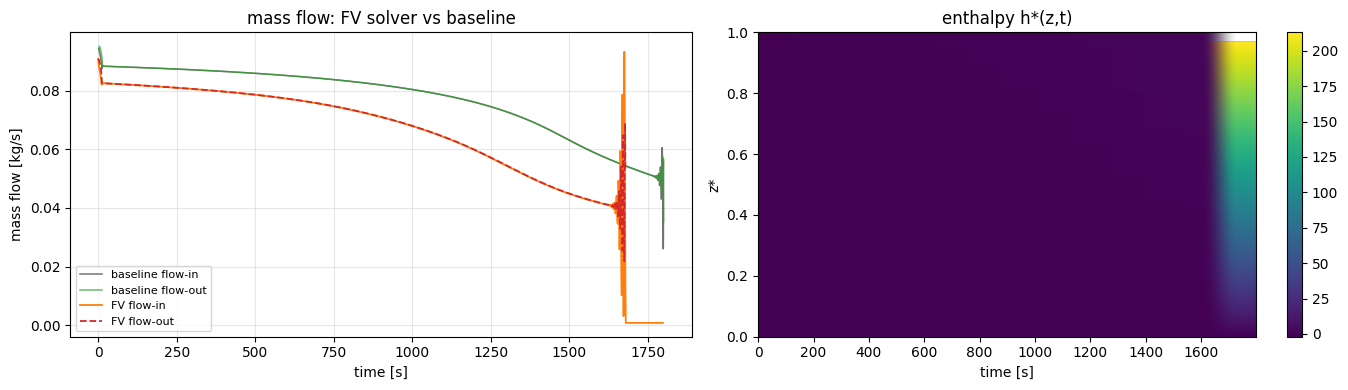

In [40]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
# baseline (reference solver, from the Churkin benchmark Excel via `forcing`)
ax[0].plot(forcing.time, forcing.flow_in, color='k', lw=1.1, alpha=0.55, label='baseline flow-in')
ax[0].plot(forcing.time, forcing.flow_out, color='tab:green', lw=1.1, alpha=0.7, label='baseline flow-out')
# FV solver
ax[0].plot(out['t_sec'], out['Gin_kgs'], color='tab:orange', lw=1.3, label='FV flow-in')
ax[0].plot(out['t_sec'], out['Gout_kgs'], '--', color='tab:red', lw=1.3, label='FV flow-out')
ax[0].set_xlabel('time [s]'); ax[0].set_ylabel('mass flow [kg/s]')
ax[0].set_title('mass flow: FV solver vs baseline'); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3)
# enthalpy space-time
im = ax[1].imshow(out['hsnap'].T, aspect='auto', origin='lower',
                  extent=[out['tsnap'][0]*case.L/case.w0, out['tsnap'][-1]*case.L/case.w0, 0, 1])
ax[1].set_xlabel('time [s]'); ax[1].set_ylabel('z*'); ax[1].set_title('enthalpy h*(z,t)')
fig.colorbar(im, ax=ax[1]); plt.tight_layout(); plt.show()

### Notes / next steps
- **Grid convergence:** rerun with `N=300` (damped, envelope only) vs `N=600/800` (DWO appears) to
  see the dissipation sensitivity. Amplitude/period are only trustworthy once grid-converged.
- **Knobs:** `N` (resolution / numerical diffusion), `dt` (temporal damping). Momentum inertia is
  now the exact integral (no knob); `inertia=<float>` switches back to the legacy lumped model
  for comparison (too large over-damps, too small makes the feedback stiff).
- **EOS tail:** the smooth `1/h` extension keeps stagnation excursions physical (no spline
  extrapolation garbage). Amplitude beyond onset is still numerics-sensitive — grid-converge first.
- **Differentiable:** the whole march is torch under `no_grad` here; drop `no_grad` and replace the
  `brentq` inlet solve with a differentiable Newton to backprop through the solver (for calibrating
  an uncertain closure or stability-boundary inverse problems — the only genuine role for a network
  in variant A).